# Eksperiment 2-2 - SMA(5)

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from experiment_utils import run_one_experiment, save_result_v1, run, MLPClassifier

import warnings
warnings.filterwarnings('ignore')

## Podaci

In [2]:
df = pd.read_csv('../data/Processed_Project_Data/fifa_and_elo_rankings_clean_filled.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df['date'] = pd.to_datetime(df['date'], format='mixed')
df = df.sort_values('date').reset_index(drop=True)

print(f'Ukupno meceva: {len(df)}')
print(df['result'].value_counts())

Ukupno meceva: 1239
result
 1    582
-1    371
 0    286
Name: count, dtype: int64


## SMA(5)

In [3]:
home_rows = df[['date', 'home_team', 'result']].rename(columns={'home_team': 'team', 'result': 'team_result'})
away_rows = df[['date', 'away_team', 'result']].copy()
away_rows['team_result'] = -away_rows['result']
away_rows = away_rows[['date', 'away_team', 'team_result']].rename(columns={'away_team': 'team'})

team_results = pd.concat([home_rows, away_rows]).sort_values('date').reset_index(drop=True)
team_results['sma5'] = (
    team_results.groupby('team')['team_result']
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

df = df.merge(team_results.rename(columns={'team': 'home_team', 'sma5': 'home_form_sma5'})[['date', 'home_team', 'home_form_sma5']], on=['date', 'home_team'], how='left')
df = df.merge(team_results.rename(columns={'team': 'away_team', 'sma5': 'away_form_sma5'})[['date', 'away_team', 'away_form_sma5']], on=['date', 'away_team'], how='left')
df = df.dropna(subset=['home_form_sma5', 'away_form_sma5']).reset_index(drop=True)

print(f'Meceva nakon filtriranja: {len(df)}')

Meceva nakon filtriranja: 614


## Priprema i pokretanje

In [4]:
X = df[['home_form_sma5', 'away_form_sma5']].values
le = LabelEncoder()
y = le.fit_transform(df['result'].values)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state = 42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_train_t = torch.tensor(y_train,    dtype=torch.long)
X_test_t  = torch.tensor(X_test_sc,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,     dtype=torch.long)


In [5]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_t.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.9461 | val loss = 0.9603 | val acc = 0.5354
Epoch 100/1000 | train loss = 0.9499 | val loss = 0.9661 | val acc = 0.5556
Epoch 150/1000 | train loss = 0.9468 | val loss = 0.9694 | val acc = 0.5556
Epoch 200/1000 | train loss = 0.9533 | val loss = 0.9733 | val acc = 0.5556
Epoch 250/1000 | train loss = 0.9386 | val loss = 0.9728 | val acc = 0.5556
Epoch 300/1000 | train loss = 0.9310 | val loss = 0.9755 | val acc = 0.5556
Epoch 350/1000 | train loss = 0.9323 | val loss = 0.9833 | val acc = 0.5556
Epoch 400/1000 | train loss = 0.9342 | val loss = 0.9853 | val acc = 0.5556
Epoch 450/1000 | train loss = 0.9363 | val loss = 0.9901 | val acc = 0.5556
Epoch 500/1000 | train loss = 0.9234 | val loss = 0.9893 | val acc = 0.5556
Epoch 550/1000 | train loss = 0.9332 | val loss = 0.9969 | val acc = 0.5556
Epoch 600/1000 | train loss = 0.9192 | val loss = 0.9961 | val acc = 0.5556
Epoch 650/1000 | train loss = 0.9217 | val loss = 1.0017 | val acc = 0.5556
Epoch 700/100

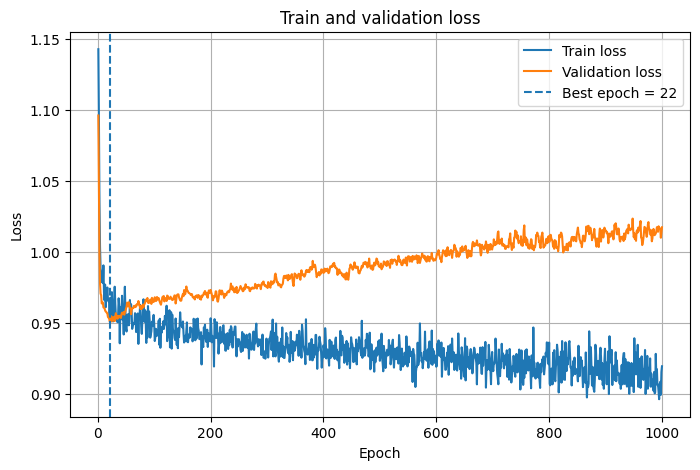

0.6422764227642277

In [6]:
run_one_experiment(model, criterion, optimizer, X_train_t, y_train_t, X_test_t, y_test_t)

In [8]:
best_num_epochs = 22

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_t,
    y_train_tensor=y_train_t,
    X_test_tensor=X_test_t,
    y_test_tensor=y_test_t,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.6423 | Precision: 0.4168 | Recall: 0.5410 | Specificity: 0.7896 | F1: 0.4708

Run 2/10
Accuracy: 0.6341 | Precision: 0.4103 | Recall: 0.5255 | Specificity: 0.7822 | F1: 0.4605

Run 3/10
Accuracy: 0.6423 | Precision: 0.4231 | Recall: 0.5256 | Specificity: 0.7802 | F1: 0.4665

Run 4/10
Accuracy: 0.6423 | Precision: 0.4231 | Recall: 0.5256 | Specificity: 0.7802 | F1: 0.4665

Run 5/10
Accuracy: 0.6260 | Precision: 0.4121 | Recall: 0.5150 | Specificity: 0.7709 | F1: 0.4562

Run 6/10
Accuracy: 0.6341 | Precision: 0.4153 | Recall: 0.5255 | Specificity: 0.7784 | F1: 0.4631

Run 7/10
Accuracy: 0.6260 | Precision: 0.4121 | Recall: 0.5150 | Specificity: 0.7709 | F1: 0.4562

Run 8/10
Accuracy: 0.6341 | Precision: 0.4208 | Recall: 0.5152 | Specificity: 0.7727 | F1: 0.4594

Run 9/10
Accuracy: 0.6260 | Precision: 0.4038 | Recall: 0.5150 | Specificity: 0.7766 | F1: 0.4523

Run 10/10
Accuracy: 0.6341 | Precision: 0.4153 | Recall: 0.5255 | Specificity: 0.7784 | F1: 0.4631

Summary o

In [9]:
save_result_v1(
    experiment_name="Experiment_2-2_SMA5",
    summary=summary
)


Saved result for Experiment_2-2_SMA5
File: ../results/experiment_summary_v1.csv
